In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
!ls /grid/kinney/home/desmara/PacBioMapping/Jack/

bc2011.aligned.ecoli.coverage	     bc2011.aligned.lib001.coverage
bc2011.aligned.ecoli.sorted.bam      bc2011.aligned.lib001.sorted.bam
bc2011.aligned.ecoli.sorted.bam.bai  bc2011.aligned.lib001.sorted.bam.bai


In [ ]:
genome_coverage = pd.read_csv('/grid/kinney/home/desmara/PacBioMapping/Jack/bc2011.aligned.ecoli.coverage', sep='\t', header=0)
genome_coverage = genome_coverage.rename(columns={'#CHROM': 'chromosome', '/grid/kinney/home/desmara/PacBioMapping/Jack/bc2011.aligned.ecoli.sorted.bam': 'coverage'})
genome_coverage

,chromosome,POS,coverage
0,CP070482.1,1,294
1,CP070482.1,2,295
2,CP070482.1,3,295
3,CP070482.1,4,295
4,CP070482.1,5,295
...,...,...,...
4631437,CP070482.1,4631438,296
4631438,CP070482.1,4631439,296
4631439,CP070482.1,4631440,294
4631440,CP070482.1,4631441,293


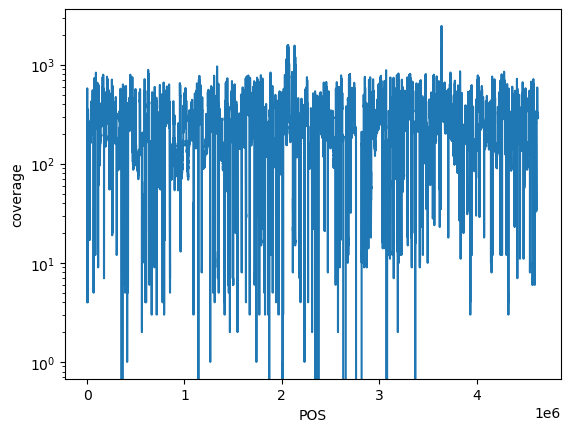

In [ ]:
sns.lineplot(x='POS', y='coverage', data=genome_coverage)
plt.yscale('log')   

In [2]:
plasmid_coverage = pd.read_csv('/grid/kinney/home/desmara/PacBioMapping/Jack/bc2011.aligned.lib001.coverage', sep='\t', header=0)
plasmid_coverage = plasmid_coverage.rename(columns={'#CHROM': 'chromosome', '/grid/kinney/home/desmara/PacBioMapping/Jack/bc2011.aligned.lib001.sorted.bam': 'coverage', 'POS': 'Position in plasmid'})
plasmid_coverage

,chromosome,Position in plasmid,coverage
0,library001_ris_sensative_SMN2_2xInner_2xBC,1,6097880
1,library001_ris_sensative_SMN2_2xInner_2xBC,2,6099234
2,library001_ris_sensative_SMN2_2xInner_2xBC,3,6101209
3,library001_ris_sensative_SMN2_2xInner_2xBC,4,6101964
4,library001_ris_sensative_SMN2_2xInner_2xBC,5,6123977
...,...,...,...
4380,library001_ris_sensative_SMN2_2xInner_2xBC,4381,6147413
4381,library001_ris_sensative_SMN2_2xInner_2xBC,4382,6147287
4382,library001_ris_sensative_SMN2_2xInner_2xBC,4383,6146965
4383,library001_ris_sensative_SMN2_2xInner_2xBC,4384,6037640


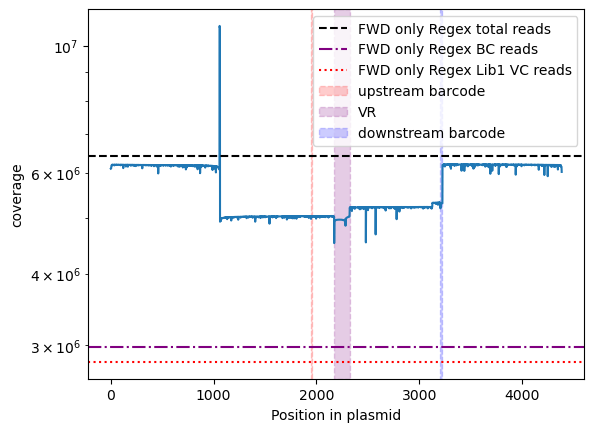

In [4]:
sns.lineplot(x='Position in plasmid', y='coverage', data=plasmid_coverage)
plt.axhline(y=6424942, color='black', linestyle='--', label='FWD only Regex total reads')
plt.axhline(y=2982911, color='purple', linestyle='-.', label='FWD only Regex BC reads')
plt.axhline(y=2804341, color='red', linestyle=':', label='FWD only Regex Lib1 VC reads')

plt.axvspan(xmax=1948, xmin=1953, color='red', linestyle='--', alpha=0.2, label='upstream barcode')
plt.axvspan(xmax=2173, xmin=2322, color='purple', linestyle='--', alpha=0.2, label='VR')
plt.axvspan(xmax=3206, xmin=3225, color='blue', linestyle='--', alpha=0.2, label='downstream barcode')
plt.yscale('log')  
plt.legend()
plt.show()


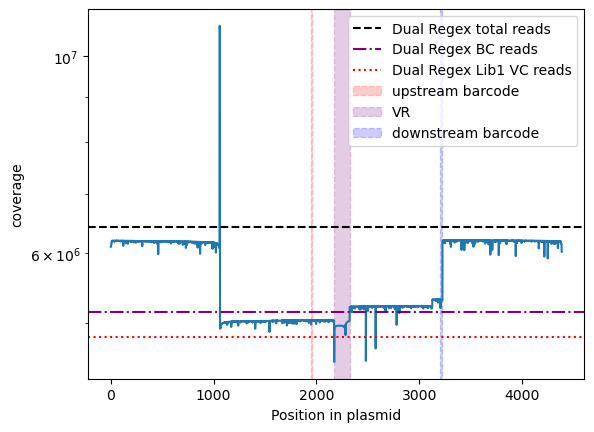

In [5]:
sns.lineplot(x='Position in plasmid', y='coverage', data=plasmid_coverage)
plt.axhline(y=6424942, color='black', linestyle='--', label='Dual Regex total reads')
plt.axhline(y=5142034, color='purple', linestyle='-.', label='Dual Regex BC reads')
plt.axhline(y=4820177, color='red', linestyle=':', label='Dual Regex Lib1 VC reads')

plt.axvspan(xmax=1948, xmin=1953, color='red', linestyle='--', alpha=0.2, label='upstream barcode')
plt.axvspan(xmax=2173, xmin=2322, color='purple', linestyle='--', alpha=0.2, label='VR')
plt.axvspan(xmax=3206, xmin=3225, color='blue', linestyle='--', alpha=0.2, label='downstream barcode')
plt.yscale('log')  
plt.legend()
plt.show()


In [6]:
import pysam
# Define BAM file and region of interest
bam_path = "/grid/kinney/home/desmara/PacBioMapping/Jack/bc2011.aligned.lib001.sorted.bam"
output_fasta = "/grid/kinney/data/desmara/2025_12_03_pac_bio_library_mapping_risLlib_001_002_003_004/aligning/lib001_minigene_mapped.fasta"
region_chr = "library001_ris_sensative_SMN2_2xInner_2xBC"  # change as needed
region_start = 2000   # 0-based, inclusive
region_end = 3000     # exclusive

# Open BAM file
bamfile = pysam.AlignmentFile(bam_path, "rb")

with open(output_fasta, "w") as fasta_out:
    for i, read in enumerate(bamfile.fetch(region_chr, region_start, region_end)):
        if i > 10:
            break
        # Only save primary alignments and properly aligned
        if read.is_unmapped or read.is_secondary or read.is_supplementary:
            continue
        seq = read.query_sequence
        if seq is None:
            continue
        fasta_out.write(f">{read.query_name}\n{seq}\n")

bamfile.close()
print(f"Finished writing reads from {region_chr}:{region_start+1}-{region_end} to {output_fasta}")


Finished writing reads from library001_ris_sensative_SMN2_2xInner_2xBC:2001-3000 to /grid/kinney/data/desmara/2025_12_03_pac_bio_library_mapping_risLlib_001_002_003_004/aligning/lib001_minigene_mapped.fasta


In [3]:
import pysam
import numpy as np
# Define BAM file and region of interest
bam_path = "/grid/kinney/home/desmara/PacBioMapping/Jack/bc2011.aligned.lib001.sorted.bam"
output_fasta = "/grid/kinney/data/desmara/2025_12_03_pac_bio_library_mapping_risLlib_001_002_003_004/aligning/lib001_backbone_mapped.fasta"
region_chr = "library001_ris_sensative_SMN2_2xInner_2xBC"  # change as needed
region_start = 3500   # 0-based, inclusive
region_end = 4000     # exclusive

# Open BAM file
bamfile = pysam.AlignmentFile(bam_path, "rb")

saved_reads = 0
with open(output_fasta, "w") as fasta_out:
    for read in bamfile.fetch(region_chr, region_start, region_end):
        if saved_reads > 10:
            break
        # Only save primary alignments and properly aligned
        if read.is_unmapped or read.is_secondary or read.is_supplementary:
            continue
        query_pos, ref_pos = zip(*read.get_aligned_pairs(matches_only=True))
        ref_pos = np.array(ref_pos)
        if not ((ref_pos<2000)|(ref_pos>3000)).all():
            continue
        seq = read.query_sequence
        if seq is None:
            continue

        saved_reads += 1
        fasta_out.write(f">{read.query_name}\n{seq}\n")

bamfile.close()
print(f"Finished writing reads from {region_chr}:{region_start+1}-{region_end} to {output_fasta}")


Finished writing reads from library001_ris_sensative_SMN2_2xInner_2xBC:3501-4000 to /grid/kinney/data/desmara/2025_12_03_pac_bio_library_mapping_risLlib_001_002_003_004/aligning/lib001_backbone_mapped.fasta


In [12]:
!samtools flagstat /grid/kinney/home/desmara/PacBioMapping/Jack/bc2011.aligned.ecoli.sorted.bam

202867 + 0 in total (QC-passed reads + QC-failed reads)
195618 + 0 primary
0 + 0 secondary
7249 + 0 supplementary
0 + 0 duplicates
0 + 0 primary duplicates
202867 + 0 mapped (100.00% : N/A)
195618 + 0 primary mapped (100.00% : N/A)
0 + 0 paired in sequencing
0 + 0 read1
0 + 0 read2
0 + 0 properly paired (N/A : N/A)
0 + 0 with itself and mate mapped
0 + 0 singletons (N/A : N/A)
0 + 0 with mate mapped to a different chr
0 + 0 with mate mapped to a different chr (mapQ>=5)


In [1]:
total_reads = 6424942
print(f'{195618}/{total_reads} ({195618/total_reads*100:.2f}%) of reads mapped to e. coli genome')

195618/6424942 (3.04%) of reads mapped to e. coli genome


In [13]:
!samtools flagstat /grid/kinney/home/desmara/PacBioMapping/Jack/bc2011.aligned.lib001.sorted.bam

12427278 + 0 in total (QC-passed reads + QC-failed reads)
6230215 + 0 primary
0 + 0 secondary
6197063 + 0 supplementary
0 + 0 duplicates
0 + 0 primary duplicates
12427278 + 0 mapped (100.00% : N/A)
6230215 + 0 primary mapped (100.00% : N/A)
0 + 0 paired in sequencing
0 + 0 read1
0 + 0 read2
0 + 0 properly paired (N/A : N/A)
0 + 0 with itself and mate mapped
0 + 0 singletons (N/A : N/A)
0 + 0 with mate mapped to a different chr
0 + 0 with mate mapped to a different chr (mapQ>=5)


In [8]:
total_reads = 6424942
print(f'{6230215}/{total_reads} ({6230215/total_reads*100:.2f}%) of reads mapped to plasmid')

6230215/6424942 (96.97%) of reads mapped to plasmid
